In [125]:
### AAE 722 Lab 12 - Charles Voigt
#Housekeeping - importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from sklearn.cluster import(KMeans, AgglomerativeClustering)
from scipy.cluster.hierarchy import (dendrogram, cut_tree)
from ISLP.cluster import compute_linkage
import warnings
warnings.filterwarnings('ignore')

In [126]:
# Chapter 12 Exercise 10 - Part a
classes = 3
samples_per_class = 20
features = 50
means = np.array([0, 1, 2])

sim = [
    np.random.normal(loc=means[i], scale=1.5, size=(samples_per_class, features))
    for i in range(classes)
]

In [127]:
# Part b
pcasim = PCA()
pcasim.fit(np.vstack(sim))

PCA()

In [128]:
scores = pcasim.transform(np.vstack(sim))

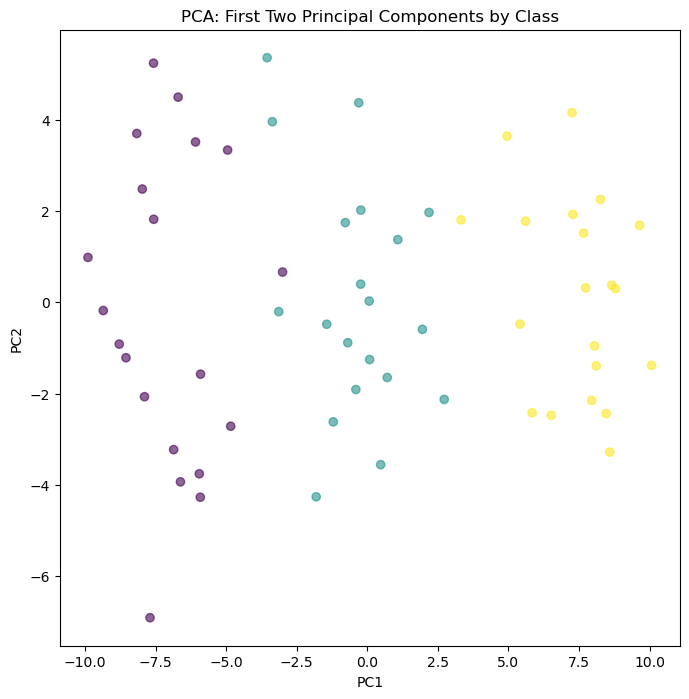

In [129]:
i, j = 0, 1  # Plot PC1 (i=0) vs PC2 (j=1)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

true_labels = np.repeat([0, 1, 2], samples_per_class)

ax.scatter(scores[:,0], scores[:,1], c=true_labels, cmap='viridis', alpha=0.6)
ax.set_xlabel('PC%d' % (i+1))  # X-axis: PC1
ax.set_ylabel('PC%d' % (j+1))  # Y-axis: PC2
ax.set_title('PCA: First Two Principal Components by Class')

plt.show()

In [130]:
# Part c
kmeanssim = KMeans(n_clusters=3, random_state=42)
kmeanssim.fit(np.vstack(sim))
labels = kmeanssim.labels_ 

Text(0.5, 1.0, 'KMeans Clustering on PCA Scores, K = 3')

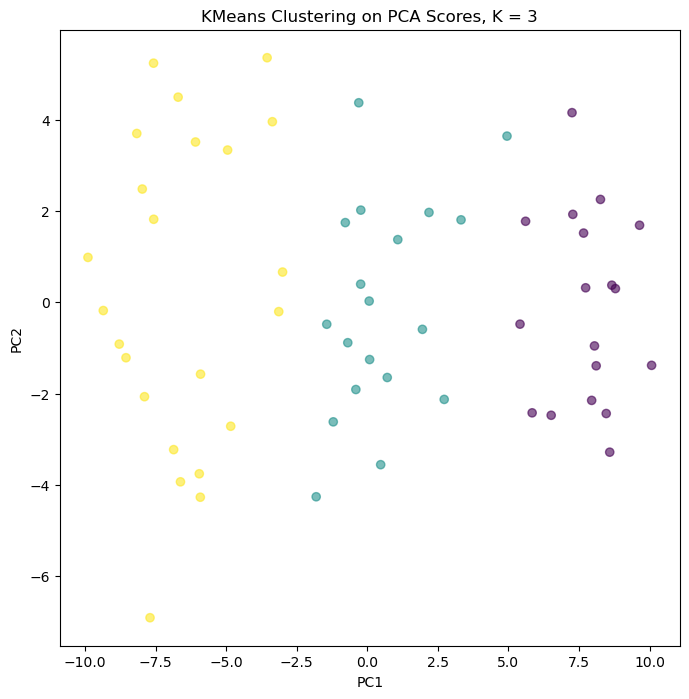

In [131]:
# Part c continued
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
c = kmeanssim.labels_
ax.scatter(scores[:,0], scores[:,1], c=c, cmap='viridis', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('KMeans Clustering on PCA Scores, K = 3')

In [132]:
# Part c continued 
pd.crosstab(labels, np.repeat([0, 1, 2], samples_per_class), rownames=['KMeans Labels'], colnames=['True Classes'])

True Classes,0,1,2
KMeans Labels,,,
0,0,0,18
1,0,17,2
2,20,3,0


Because the K-means clustering arbitrarily numbers the classes, this crosstab analysis just shows that there is slight misclassification in the first class and second class.

In [133]:
# Part d
kmeanssim2 = KMeans(n_clusters=2, random_state=42)
kmeanssim2.fit(np.vstack(sim))
labels2 = kmeanssim2.labels_

Text(0.5, 1.0, 'KMeans Clustering on PCA Scores, K = 2')

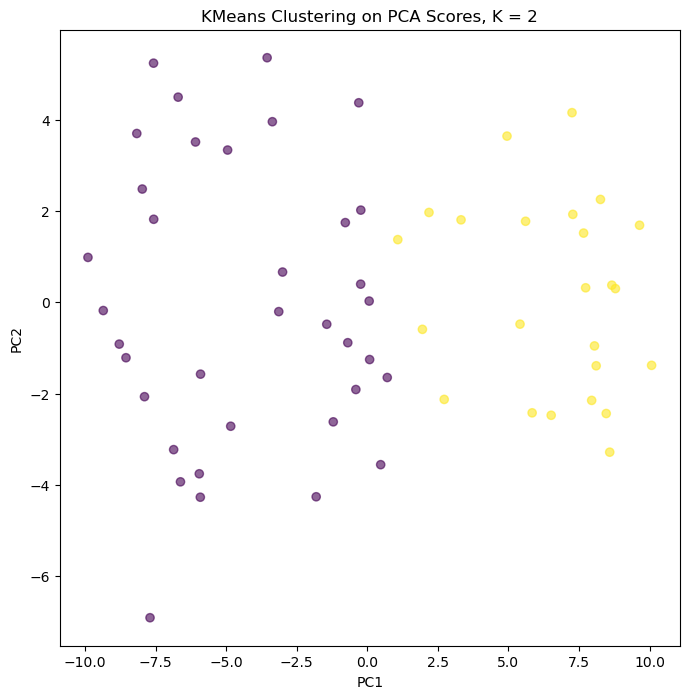

In [134]:
# Part d continued
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
c = kmeanssim2.labels_
ax.scatter(scores[:,0], scores[:,1], c=c, cmap='viridis', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('KMeans Clustering on PCA Scores, K = 2')

In [135]:
pd.crosstab(kmeanssim2.labels_, np.repeat([0, 1, 2], samples_per_class), rownames=['KMeans Labels'], colnames=['True Classes'])

True Classes,0,1,2
KMeans Labels,,,
0,20,16,0
1,0,4,20


Using K = 2 causes one of the true classes to be split among the remaining 2 classes, in this case with 5 going to one class and 15 going to the other.

In [136]:
# Part e
kmeanssim4 = KMeans(n_clusters=4, random_state=42)
kmeanssim4.fit(np.vstack(sim))
labels4 = kmeanssim4.labels_

Text(0.5, 1.0, 'KMeans Clustering on PCA Scores, K = 4')

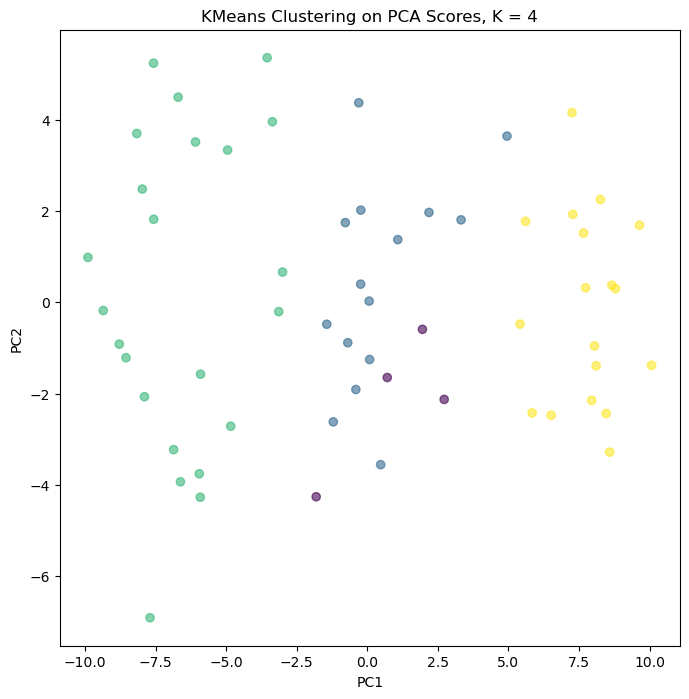

In [137]:
# Part e continued
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
c = kmeanssim4.labels_
ax.scatter(scores[:,0], scores[:,1], c=c, cmap='viridis', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('KMeans Clustering on PCA Scores, K = 4')

In [138]:
pd.crosstab(kmeanssim4.labels_, np.repeat([0, 1, 2], samples_per_class), rownames=['KMeans Labels'], colnames=['True Classes'])

True Classes,0,1,2
KMeans Labels,,,
0,0,4,0
1,0,13,2
2,20,3,0
3,0,0,18


Setting K = 4 causes there to be a fourth class, which appears to use observations belonging to the true 3rd class.

In [139]:
# Part f
scores_2d = scores[:, :2]
kmeans_pc = KMeans(n_clusters=3, random_state=42)
kmeans_pc.fit(scores_2d)
labels_pc = kmeans_pc.labels_

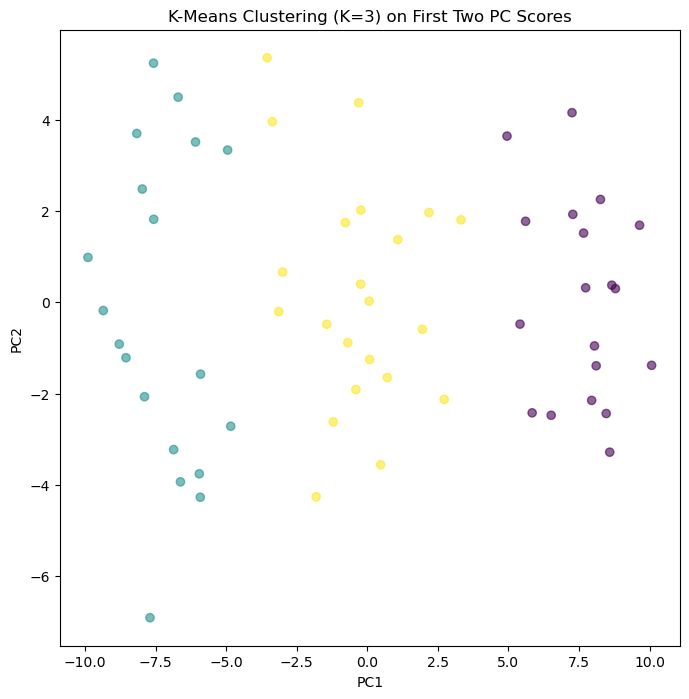

In [140]:
# Part f continued
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores_2d[:,0], scores_2d[:,1], c=labels_pc, cmap='viridis', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-Means Clustering (K=3) on First Two PC Scores')
plt.show()

In [141]:
# Part f continued
true_labels = np.repeat([0, 1, 2], samples_per_class)
pd.crosstab(labels_pc, true_labels, rownames=['KMeans on PC Scores'], colnames=['True Classes'])

True Classes,0,1,2
KMeans on PC Scores,,,
0,0,0,19
1,19,0,0
2,1,20,1


This method of K means clustering yields a slightly more accurate result than just using the raw data.

In [142]:
# Part g
standardscaler = StandardScaler(with_mean=True, with_std=True)
standardscalersim = standardscaler.fit_transform(np.vstack(sim))

standardscalerkmeans = KMeans(n_clusters=3, random_state=42)
standardscalerkmeans.fit(standardscalersim)
standardscalerkmeans.labels_
pd.crosstab(standardscalerkmeans.labels_, np.repeat([0, 1, 2], samples_per_class), rownames=['KMeans on Standardized Data'], colnames=['True Classes'])

True Classes,0,1,2
KMeans on Standardized Data,,,
0,0,2,18
1,0,14,2
2,20,4,0


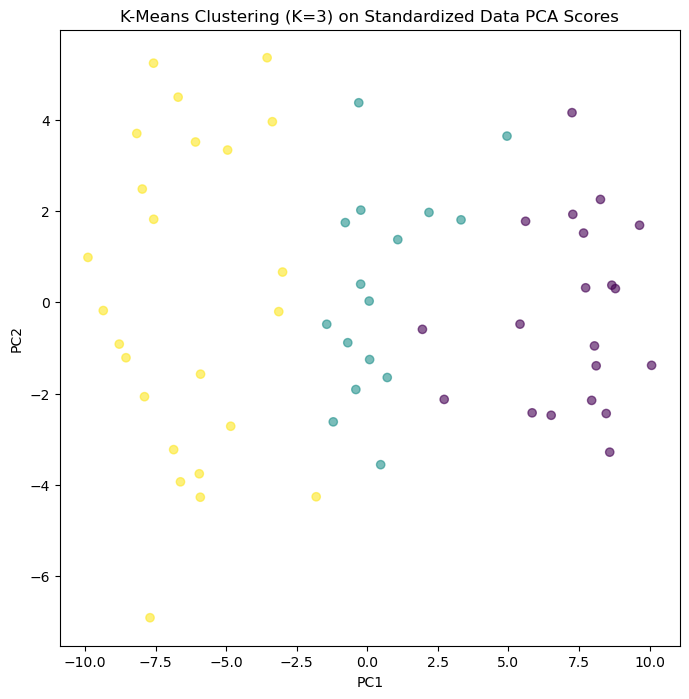

In [143]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
c = standardscalerkmeans.labels_
ax.scatter(scores[:,0], scores[:,1], c=c, cmap='viridis', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-Means Clustering (K=3) on Standardized Data PCA Scores')
plt.show()

This method yields results nearly identical to those in part b. This is because the data generation process created data with proportional scales = 1.5, thus standardizing all SD = 1 did not change the underlying proportions of the data.